# la transformada de fourier aplicada en procesamiento de imagenes

Esta trasformada se usa para analizar la frecuencia de las imágenes, lo que permite identificar patrones y características que no son evidentes en el dominio espacial. Al aplicar la transformada de Fourier a una imagen, se obtiene una representación en el dominio de la frecuencia, donde cada punto representa una frecuencia específica presente en la imagen. Esto es especialmente útil para tareas como la eliminación de ruido, la mejora de la calidad de la imagen y la compresión de datos. Además, la transformada de Fourier facilita la realización de operaciones como la convolución y la correlación, que son fundamentales en el procesamiento de imágenes para tareas como el filtrado y la detección de bordes. En resumen, la transformada de Fourier es una herramienta esencial en el procesamiento de imágenes que permite analizar y manipular las frecuencias presentes en una imagen para mejorar su calidad y extraer información relevante.

La convolucion cortamente es una operación matemática que se utiliza para combinar dos funciones, en este caso, una imagen y un filtro o kernel. En el procesamiento de imágenes, la convolución se emplea para aplicar efectos como el desenfoque, la detección de bordes y la mejora de la calidad de la imagen. La operación de convolución implica deslizar el kernel sobre la imagen y calcular la suma ponderada de los valores de los píxeles cubiertos por el kernel en cada posición. El resultado es una nueva imagen que ha sido transformada según las características del kernel utilizado. Por ejemplo, un kernel de desenfoque suaviza la imagen al promediar los valores de los píxeles cercanos, mientras que un kernel de detección de bordes resalta las áreas donde hay cambios abruptos en la intensidad de los píxeles. En resumen, la convolución es una técnica fundamental en el procesamiento de imágenes que permite modificar y mejorar las imágenes mediante la aplicación de filtros específicos. 

La transformada mejoro esto al permitir realizar la convolución de manera más eficiente en el dominio de la frecuencia. En lugar de realizar la convolución directamente en el dominio espacial, se puede aplicar la transformada de Fourier a la imagen y al kernel, multiplicar sus representaciones en el dominio de la frecuencia y luego aplicar la transformada inversa para obtener el resultado en el dominio espacial. Este enfoque es especialmente beneficioso para imágenes grandes y kernels complejos, ya que reduce significativamente el tiempo de procesamiento. Además, la transformada de Fourier permite analizar las frecuencias presentes en la imagen y ajustar los filtros de manera más precisa para obtener resultados deseados, como mejorar la nitidez o eliminar el ruido. En resumen, la transformada de Fourier optimiza el proceso de convolución en el procesamiento de imágenes, haciendo que sea más rápido y efectivo.

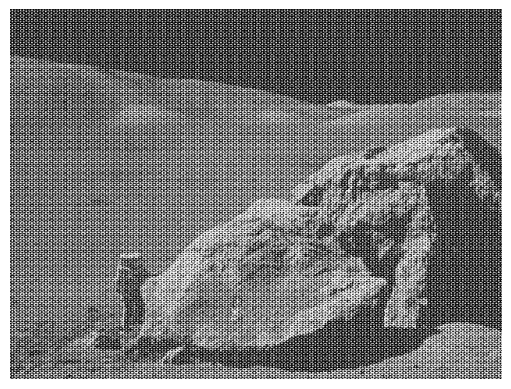

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('./moon.png').convert('RGB')

plt.imshow(img)
plt.axis('off')
plt.show()


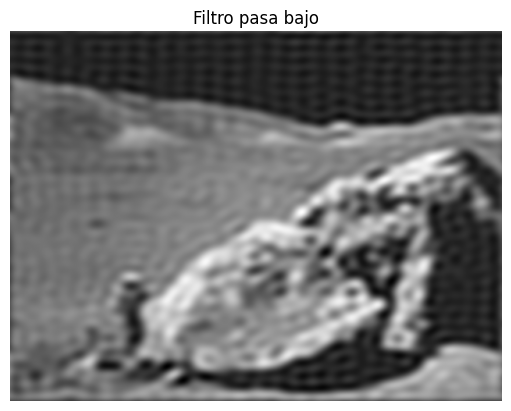

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# cargar imagen correctamente
img = Image.open('./moon.png')

# convertir a gris
gray_img = img.convert('L')
img_array = np.array(gray_img)

# Fourier
f_transform = np.fft.fft2(img_array)
f_shifted = np.fft.fftshift(f_transform)

# dimensiones
rows, cols = img_array.shape
crow, ccol = rows // 2, cols // 2

# máscara pasa bajo
mask = np.zeros((rows, cols), dtype=np.uint8)

r = 30  # radio del filtro
Y, X = np.ogrid[:rows, :cols]
dist_from_center = np.sqrt((X - ccol)**2 + (Y - crow)**2)

mask[dist_from_center <= r] = 1  # 🔥 aquí está el cambio clave

# aplicar máscara
f_shifted_filtered = f_shifted * mask

# inversa
f_ishifted = np.fft.ifftshift(f_shifted_filtered)
img_filtered = np.fft.ifft2(f_ishifted)
img_filtered = np.abs(img_filtered)

# mostrar
plt.imshow(img_filtered, cmap='gray')
plt.axis('off')
plt.title("Filtro pasa bajo")
plt.show()

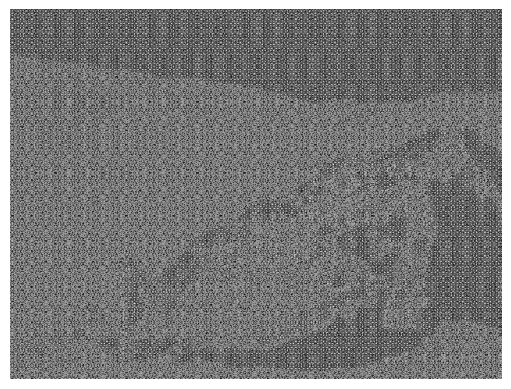

In [26]:
# vamos a aplicar un filtro pasa alto usando la transformada de Fourier
import numpy as np
# Convertir la imagen a escala de grises
gray_img = img.convert('L')
# Convertir la imagen a un array de numpy
img_array = np.array(gray_img)
# Aplicar la transformada de Fourier
f_transform = np.fft.fft2(img_array)
# Desplazar el componente de frecuencia cero al centro del espectro
f_shifted = np.fft.fftshift(f_transform)
# Crear un filtro pasa alto
rows, cols = img_array.shape
crow, ccol = rows // 2, cols // 2
# Crear una máscara de filtro pasa alto
mask = np.ones((rows, cols), dtype=np.uint8)
r = 30  # Radio del filtro pasa alto
center = (crow, ccol)   
Y, X = np.ogrid[:rows, :cols]
dist_from_center = np.sqrt((X - center[1])**2 + (Y - center[0])**2)
mask[dist_from_center <= r] = 0
# Aplicar la máscara al espectro de frecuencias
f_shifted_filtered = f_shifted * mask
# Desplazar el espectro de frecuencias de nuevo
f_ishifted = np.fft.ifftshift(f_shifted_filtered)
# Aplicar la transformada inversa de Fourier para obtener la imagen filtrada
img_filtered = np.fft.ifft2(f_ishifted)
img_filtered = np.abs(img_filtered)
# Mostrar la imagen filtrada
plt.imshow(img_filtered, cmap='gray')
plt.axis('off')
plt.show()

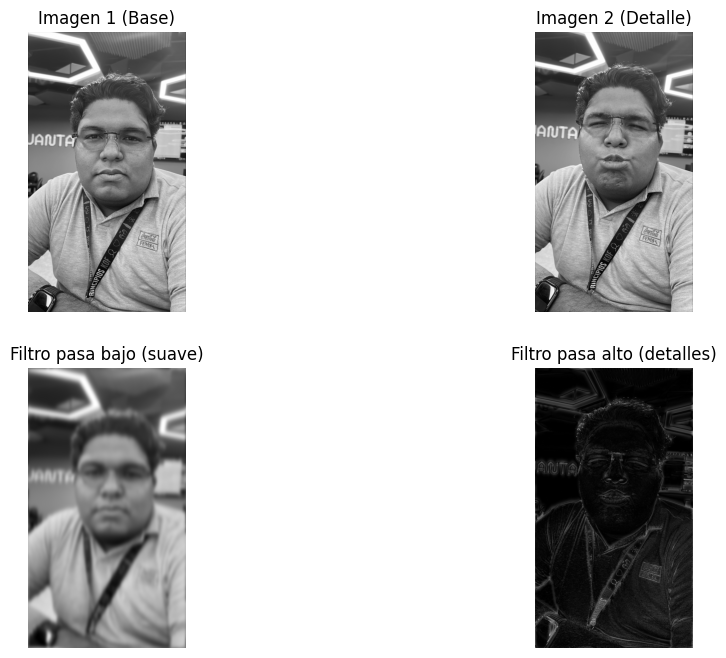

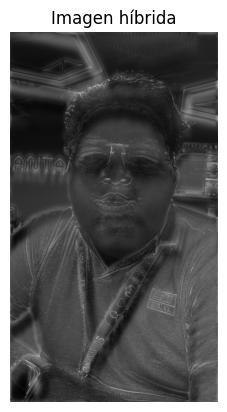

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# cargar imágenes
imagen_1 = Image.open('./Image.jpg').convert('L')
imagen_2 = Image.open('./Image (1).jpg').convert('L')

# asegurar mismo tamaño
imagen_2 = imagen_2.resize(imagen_1.size)

img1 = np.array(imagen_1, dtype=np.float32)
img2 = np.array(imagen_2, dtype=np.float32)

# Fourier
f1 = np.fft.fftshift(np.fft.fft2(img1))
f2 = np.fft.fftshift(np.fft.fft2(img2))

rows, cols = img1.shape
crow, ccol = rows // 2, cols // 2

# crear filtro gaussiano (mucho mejor que circular duro)
sigma = 20  # controla suavidad

Y, X = np.ogrid[:rows, :cols]
gaussian = np.exp(-((X - ccol)**2 + (Y - crow)**2) / (2 * sigma**2))

# pasa bajo (imagen 1)
low_pass = f1 * gaussian

# pasa alto (imagen 2)
high_pass = f2 * (1 - gaussian)

# inversa
img1_low = np.abs(np.fft.ifft2(np.fft.ifftshift(low_pass)))
img2_high = np.abs(np.fft.ifft2(np.fft.ifftshift(high_pass)))

# normalizar individualmente (clave para balance)
img1_low = img1_low / img1_low.max()
img2_high = img2_high / img2_high.max()

# pesos para controlar efecto visual
alpha = 0.6  # peso bajas frecuencias
beta = 1.2   # peso altas frecuencias (más fuerte para efecto perceptual)

img_hybrid = alpha * img1_low + beta * img2_high

# normalización final
img_hybrid = img_hybrid / img_hybrid.max()

# visualización
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img1, cmap='gray')
plt.title('Imagen 1 (Base)')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(img2, cmap='gray')
plt.title('Imagen 2 (Detalle)')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(img1_low, cmap='gray')
plt.title('Filtro pasa bajo (suave)')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(img2_high, cmap='gray')
plt.title('Filtro pasa alto (detalles)')
plt.axis('off')

plt.figure()
plt.imshow(img_hybrid, cmap='gray')
plt.title('Imagen híbrida')
plt.axis('off')

plt.show()